# Step 1: Import Libraries & Load Dataset

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
# Step 2: Load dataset
df = pd.read_csv("cleaned_startup_data.csv")  # Change path if needed


df.head()



,Unnamed: 0.1,category_code,status,founded_at,country_code,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,...,lng,founded_at_year,first_funding_at_year,last_funding_at_year,first_milestone_at_year,last_milestone_at_year,active_status,isClosed,founded_year,company_age
0,13,41,acquired,2007-10-01,103,2008-02-26,2008-02-26,1.0,5000000.0,2008-05-01,...,-122.083851,2007,2008.0,2008.0,2008.000000,2012.000000,0,1,2007,18
1,20,4,operating,2003-01-01,103,2011-03-08,2012-01-26,3.0,10125293.0,2010-01-01,...,-97.743061,2003,2011.0,2012.0,2010.000000,2010.000000,1,0,2003,22
2,26,22,operating,2003-11-01,4,2003-11-01,2003-11-01,1.0,250000.0,2007-11-01,...,153.025124,2003,2003.0,2003.0,2007.000000,2007.000000,1,0,2003,22
3,32,8,operating,2010-10-01,103,2011-04-16,2011-04-16,1.0,100000.0,2010-10-01,...,-64.519016,2010,2011.0,2011.0,2010.000000,2010.000000,1,0,2010,15
4,36,20,operating,2006-01-01,103,2011-09-06,2012-07-10,2.0,11300000.0,NaN,...,-71.007822,2006,2011.0,2012.0,2010.244157,2010.985878,1,0,2006,19


In [2]:

df.shape

(16882, 24)

In [3]:
# Check data types and basic info
df.info()

# Check for missing values
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing %': missing_percentage
}).sort_values(by='Missing Values', ascending=False)

print("Missing Values Summary:")
print(missing_summary)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16882 entries, 0 to 16881
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0.1             16882 non-null  int64  
 1   category_code            16882 non-null  int64  
 2   status                   16882 non-null  object 
 3   founded_at               16882 non-null  object 
 4   country_code             16882 non-null  int64  
 5   first_funding_at         16831 non-null  object 
 6   last_funding_at          16831 non-null  object 
 7   funding_rounds           16882 non-null  float64
 8   funding_total_usd        16882 non-null  float64
 9   first_milestone_at       10055 non-null  object 
 10  last_milestone_at        10055 non-null  object 
 11  milestones               16882 non-null  float64
 12  relationships            16882 non-null  float64
 13  lat                      16882 non-null  float64
 14  lng                   

# 2. EDA – Visual Overview

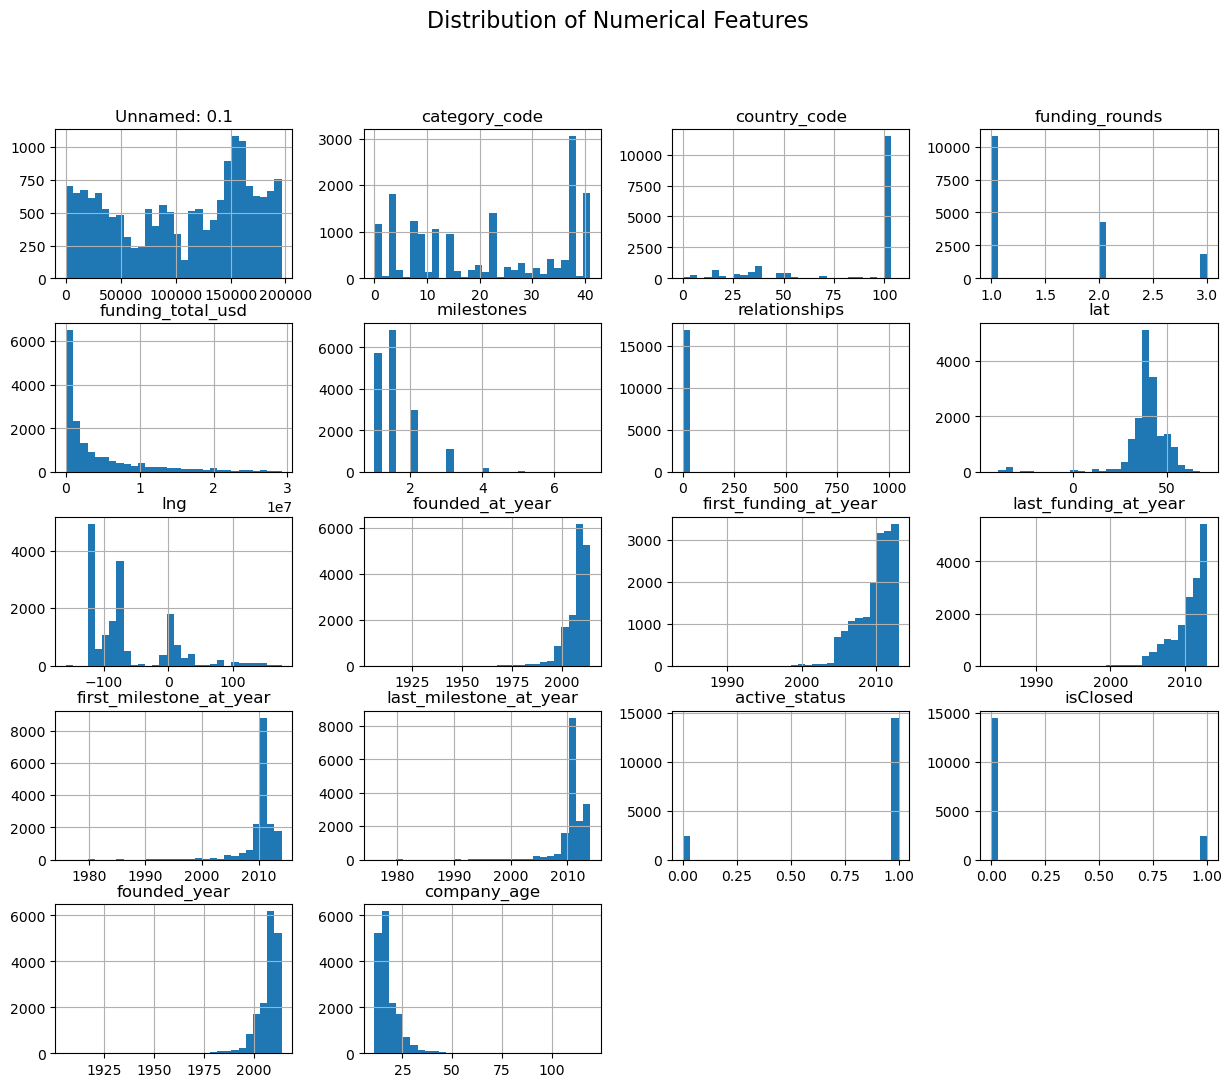

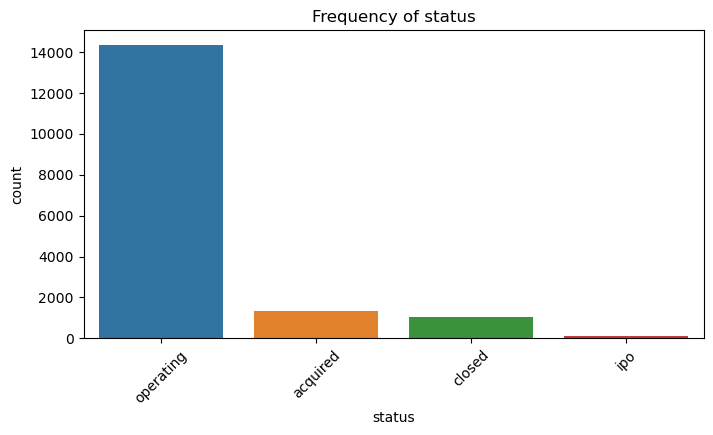

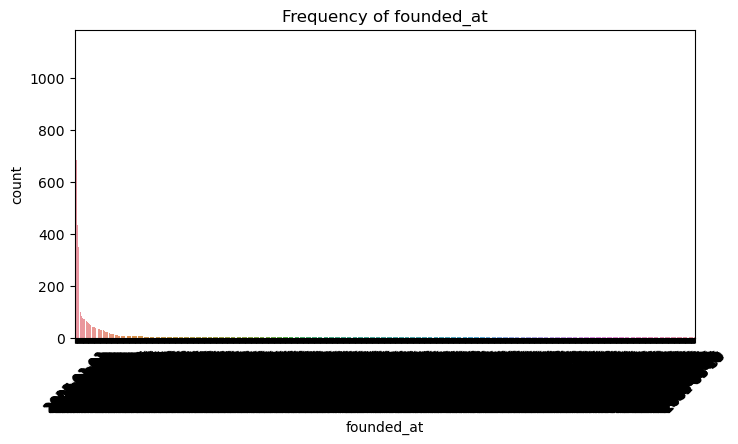

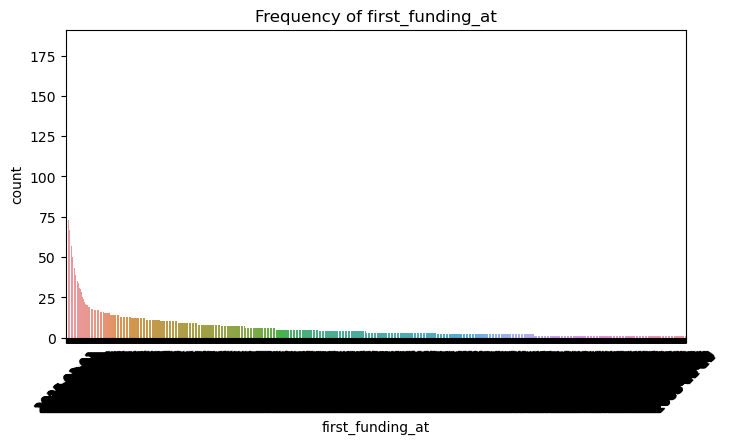

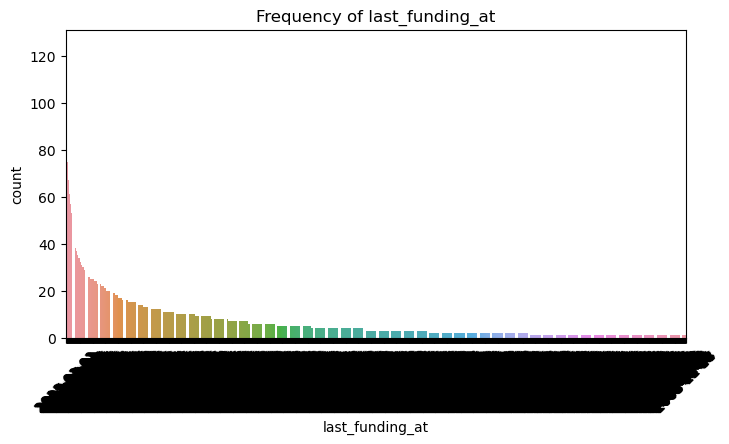

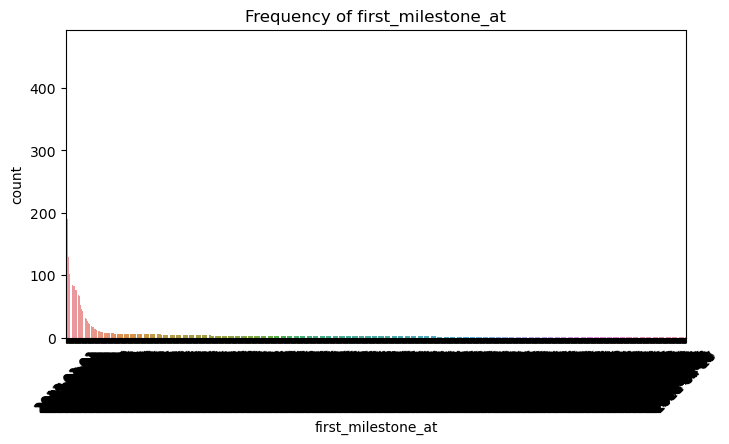

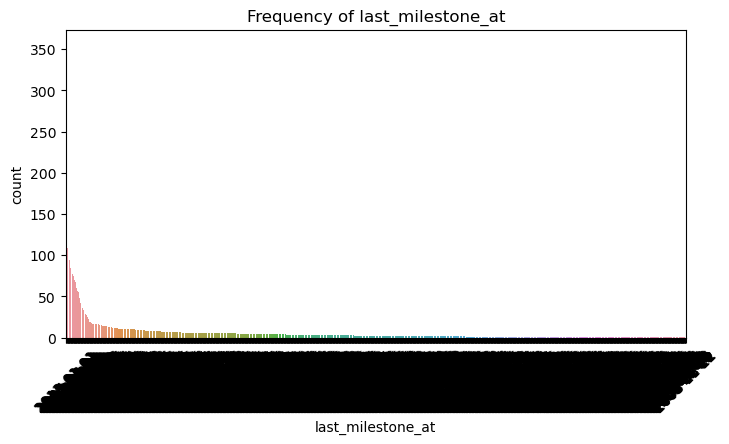

In [4]:
# Numeric and categorical column separation
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

# Distribution of numeric variables
df[numeric_cols].hist(bins=30, figsize=(15, 12))
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()

# Frequency plots for categorical variables
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Frequency of {col}")
    plt.xticks(rotation=45)
    plt.show()



In [5]:
df

,Unnamed: 0.1,category_code,status,founded_at,country_code,first_funding_at,last_funding_at,funding_rounds,funding_total_usd,first_milestone_at,...,lng,founded_at_year,first_funding_at_year,last_funding_at_year,first_milestone_at_year,last_milestone_at_year,active_status,isClosed,founded_year,company_age
0,13,41,acquired,2007-10-01,103,2008-02-26,2008-02-26,1.0,5000000.0,2008-05-01,...,-122.083851,2007,2008.0,2008.0,2008.000000,2012.000000,0,1,2007,18
1,20,4,operating,2003-01-01,103,2011-03-08,2012-01-26,3.0,10125293.0,2010-01-01,...,-97.743061,2003,2011.0,2012.0,2010.000000,2010.000000,1,0,2003,22
2,26,22,operating,2003-11-01,4,2003-11-01,2003-11-01,1.0,250000.0,2007-11-01,...,153.025124,2003,2003.0,2003.0,2007.000000,2007.000000,1,0,2003,22
3,32,8,operating,2010-10-01,103,2011-04-16,2011-04-16,1.0,100000.0,2010-10-01,...,-64.519016,2010,2011.0,2011.0,2010.000000,2010.000000,1,0,2010,15
4,36,20,operating,2006-01-01,103,2011-09-06,2012-07-10,2.0,11300000.0,NaN,...,-71.007822,2006,2011.0,2012.0,2010.244157,2010.985878,1,0,2006,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16877,196526,22,closed,2008-05-22,103,2008-05-18,2008-05-18,1.0,130000.0,2008-08-03,...,-122.419415,2008,2008.0,2008.0,2008.000000,2009.000000,0,1,2008,17
16878,196537,36,operating,2011-01-11,16,2011-09-06,2011-09-06,1.0,500000.0,2011-01-11,...,-97.003598,2011,2011.0,2011.0,2011.000000,2011.000000,1,0,2011,14
16879,196540,12,closed,2006-06-01,103,2008-03-12,2009-02-01,2.0,1100000.0,2005-11-01,...,-122.419415,2006,2008.0,2009.0,2005.000000,2008.000000,0,1,2006,19
16880,196549,31,operating,2007-11-01,103,2008-08-25,2008-08-25,1.0,750000.0,2013-05-01,...,-121.886329,2007,2008.0,2008.0,2013.000000,2013.000000,1,0,2007,18


# 3. Univariate Analysis

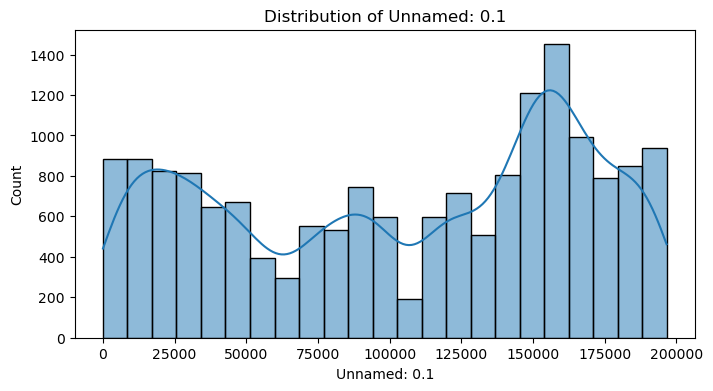

Summary stats for Unnamed: 0.1:
 count     16882.000000
mean     104991.966532
std       61113.687173
min          13.000000
25%       45016.250000
50%      116826.500000
75%      157977.000000
max      196552.000000
Name: Unnamed: 0.1, dtype: float64 



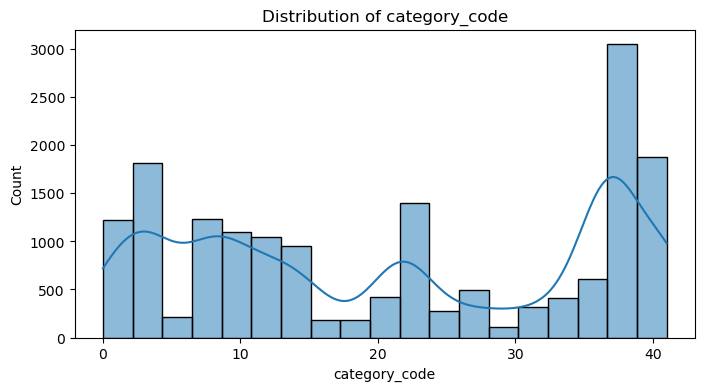

Summary stats for category_code:
 count    16882.000000
mean        21.110058
std         14.306821
min          0.000000
25%          8.000000
50%         22.000000
75%         37.000000
max         41.000000
Name: category_code, dtype: float64 



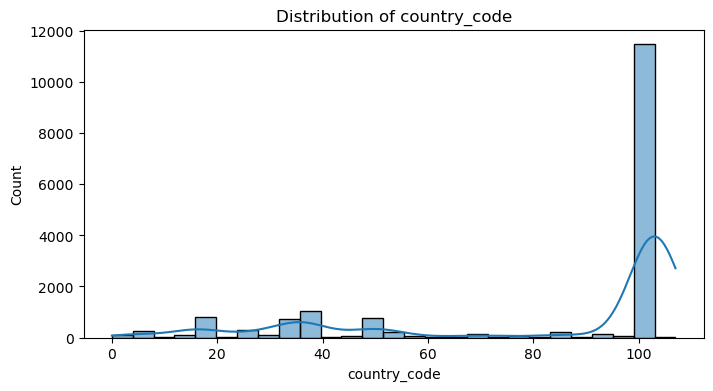

Summary stats for country_code:
 count    16882.000000
mean        82.661118
std         32.276968
min          0.000000
25%         51.000000
50%        103.000000
75%        103.000000
max        107.000000
Name: country_code, dtype: float64 



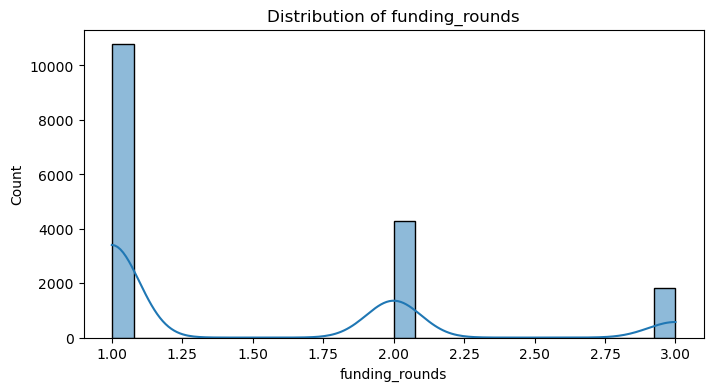

Summary stats for funding_rounds:
 count    16882.000000
mean         1.469020
std          0.681067
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          3.000000
Name: funding_rounds, dtype: float64 



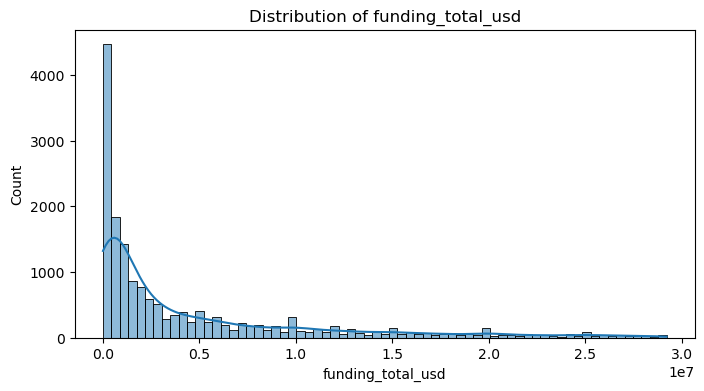

Summary stats for funding_total_usd:
 count    1.688200e+04
mean     4.561252e+06
std      6.284779e+06
min      2.910000e+02
25%      3.900900e+05
50%      1.638953e+06
75%      6.000000e+06
max      2.922000e+07
Name: funding_total_usd, dtype: float64 



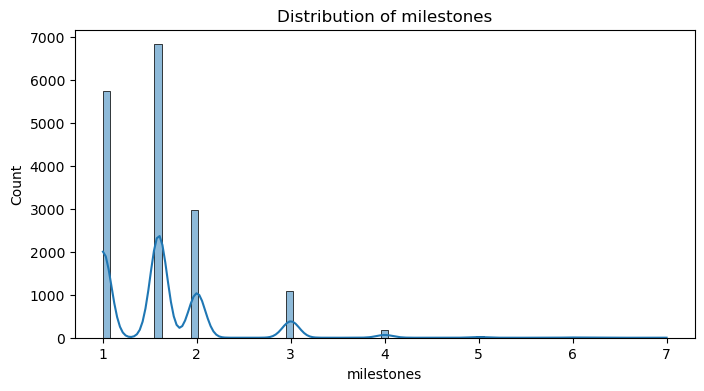

Summary stats for milestones:
 count    16882.000000
mean         1.593635
std          0.624974
min          1.000000
25%          1.000000
50%          1.593635
75%          2.000000
max          7.000000
Name: milestones, dtype: float64 



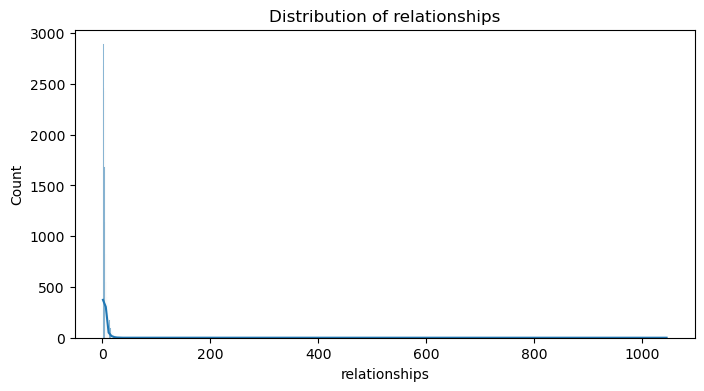

Summary stats for relationships:
 count    16882.000000
mean         4.827014
std         13.066728
min          1.000000
25%          2.000000
50%          4.000000
75%          5.000000
max       1046.000000
Name: relationships, dtype: float64 



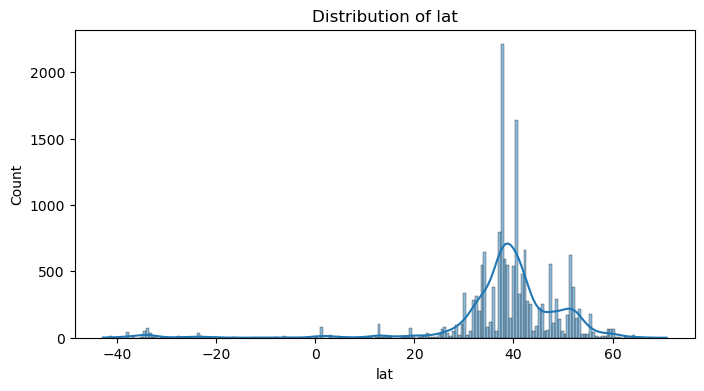

Summary stats for lat:
 count    16882.000000
mean        38.524630
std         13.168647
min        -42.883611
25%         36.162664
50%         39.083997
75%         43.589045
max         70.919200
Name: lat, dtype: float64 



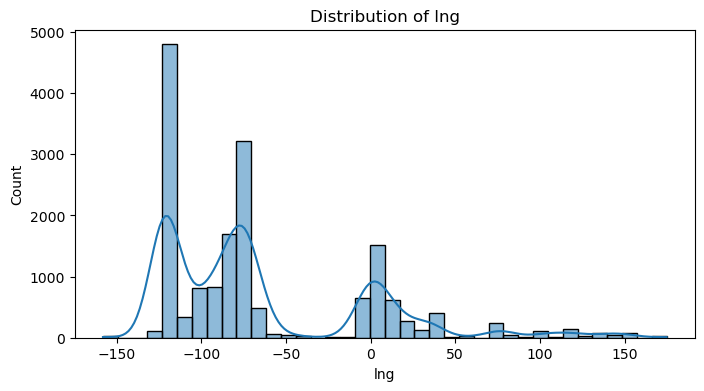

Summary stats for lng:
 count    16882.000000
mean       -64.519016
std         62.236598
min       -158.056896
25%       -118.243685
50%        -79.872181
75%         -3.987843
max        174.811945
Name: lng, dtype: float64 



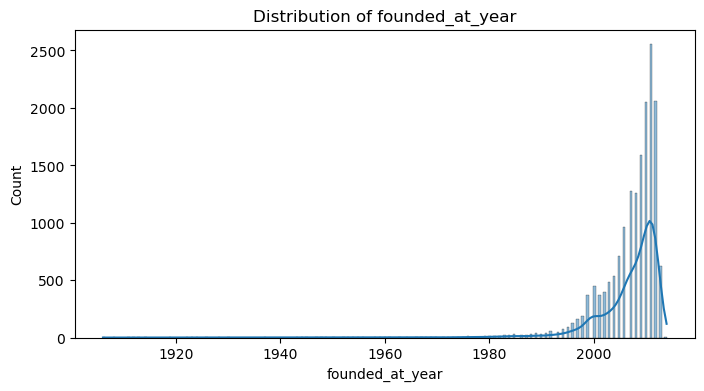

Summary stats for founded_at_year:
 count    16882.000000
mean      2006.889527
std          6.715450
min       1906.000000
25%       2005.000000
50%       2009.000000
75%       2011.000000
max       2014.000000
Name: founded_at_year, dtype: float64 



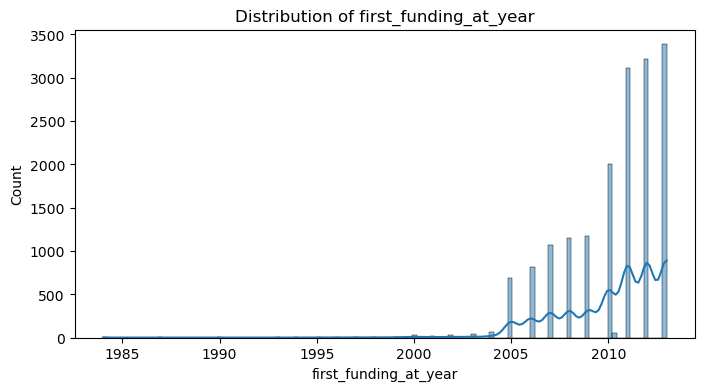

Summary stats for first_funding_at_year:
 count    16882.000000
mean      2010.261957
std          2.537160
min       1984.000000
25%       2009.000000
50%       2011.000000
75%       2012.000000
max       2013.000000
Name: first_funding_at_year, dtype: float64 



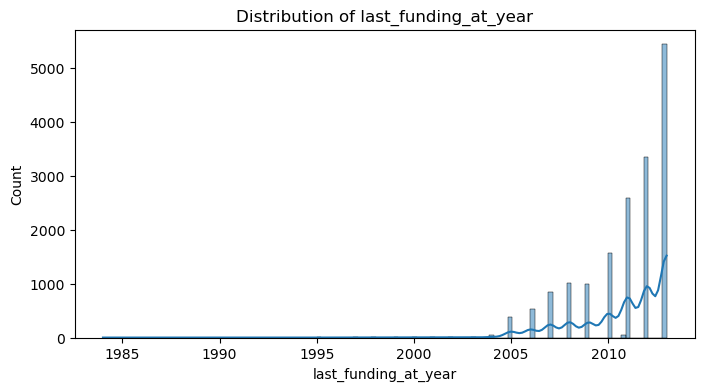

Summary stats for last_funding_at_year:
 count    16882.000000
mean      2010.881944
std          2.356860
min       1984.000000
25%       2010.000000
50%       2012.000000
75%       2013.000000
max       2013.000000
Name: last_funding_at_year, dtype: float64 



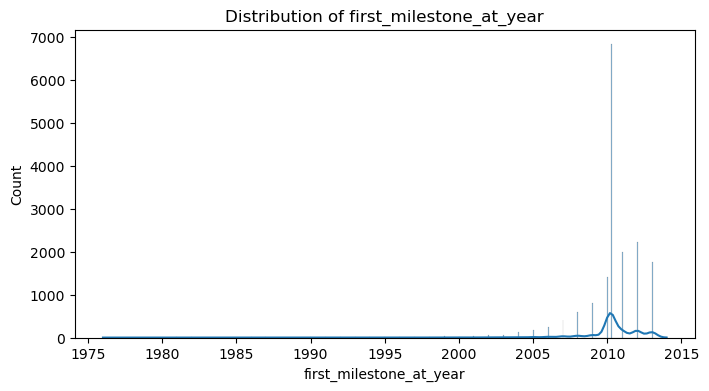

Summary stats for first_milestone_at_year:
 count    16882.000000
mean      2010.244157
std          2.312856
min       1976.000000
25%       2010.244157
50%       2010.244157
75%       2011.000000
max       2014.000000
Name: first_milestone_at_year, dtype: float64 



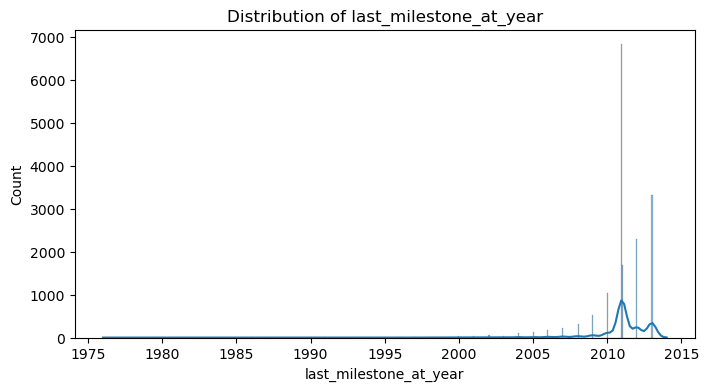

Summary stats for last_milestone_at_year:
 count    16882.000000
mean      2010.985878
std          2.154371
min       1976.000000
25%       2010.985878
50%       2010.985878
75%       2012.000000
max       2014.000000
Name: last_milestone_at_year, dtype: float64 



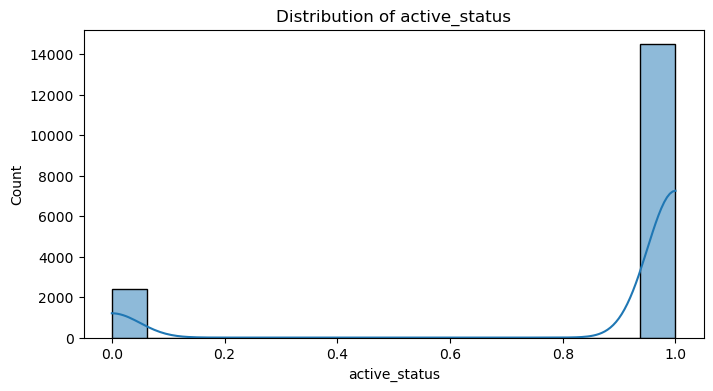

Summary stats for active_status:
 count    16882.000000
mean         0.858014
std          0.349046
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: active_status, dtype: float64 



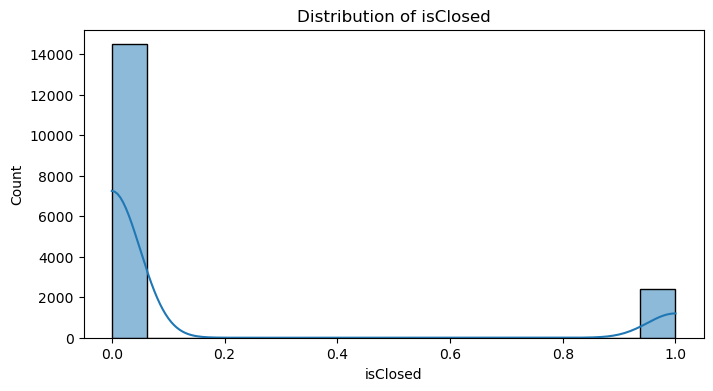

Summary stats for isClosed:
 count    16882.000000
mean         0.141986
std          0.349046
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: isClosed, dtype: float64 



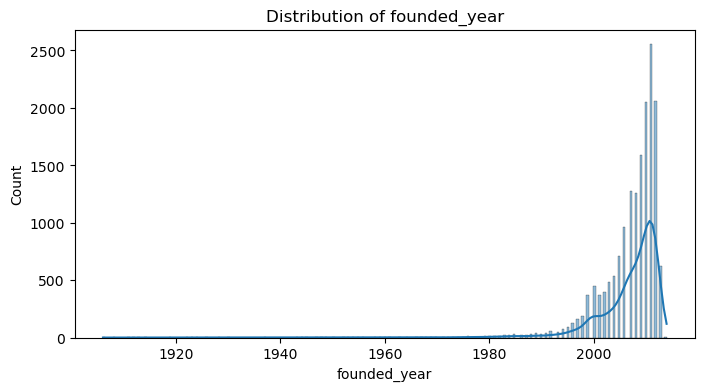

Summary stats for founded_year:
 count    16882.000000
mean      2006.889527
std          6.715450
min       1906.000000
25%       2005.000000
50%       2009.000000
75%       2011.000000
max       2014.000000
Name: founded_year, dtype: float64 



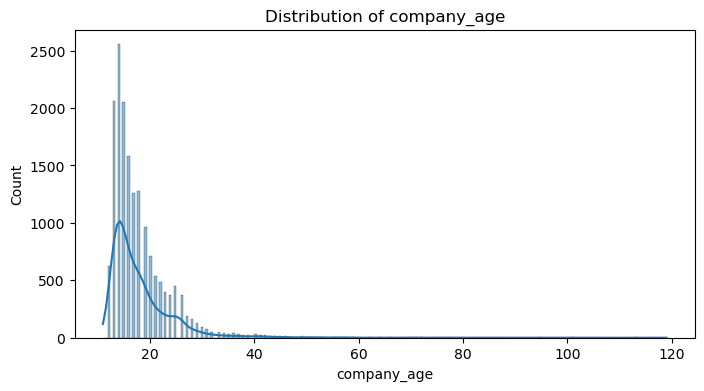

Summary stats for company_age:
 count    16882.000000
mean        18.110473
std          6.715450
min         11.000000
25%         14.000000
50%         16.000000
75%         20.000000
max        119.000000
Name: company_age, dtype: float64 



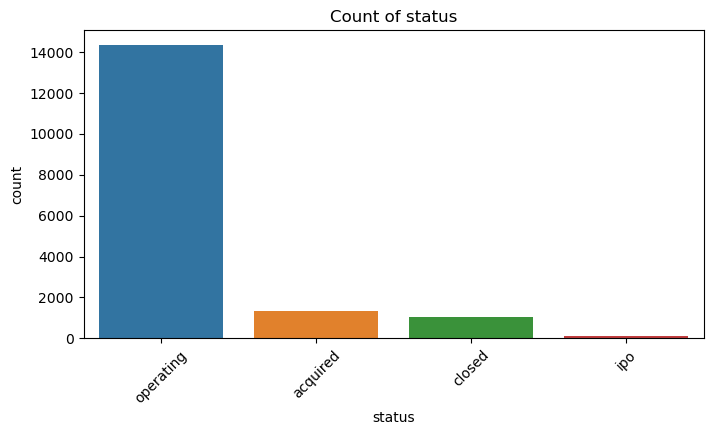

Value counts for status:
 operating    14352
acquired      1340
closed        1057
ipo            133
Name: status, dtype: int64 



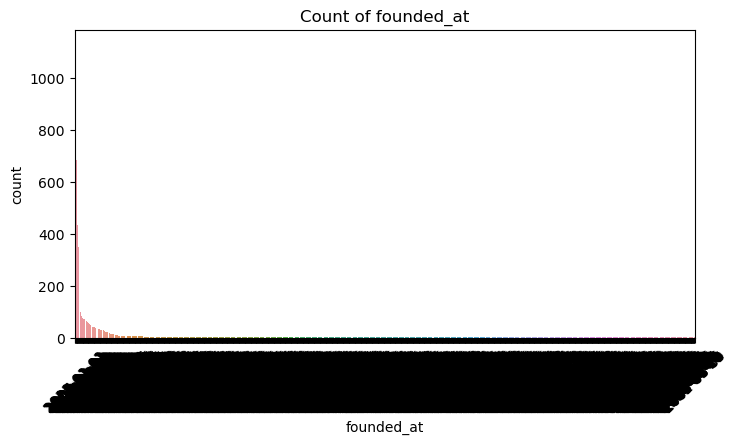

Value counts for founded_at:
 2011-01-01    1130
2010-01-01    1004
2012-01-01     855
2009-01-01     827
2007-01-01     719
              ... 
2008-08-12       1
2009-04-20       1
2012-11-19       1
2009-03-05       1
2002-06-09       1
Name: founded_at, Length: 1967, dtype: int64 



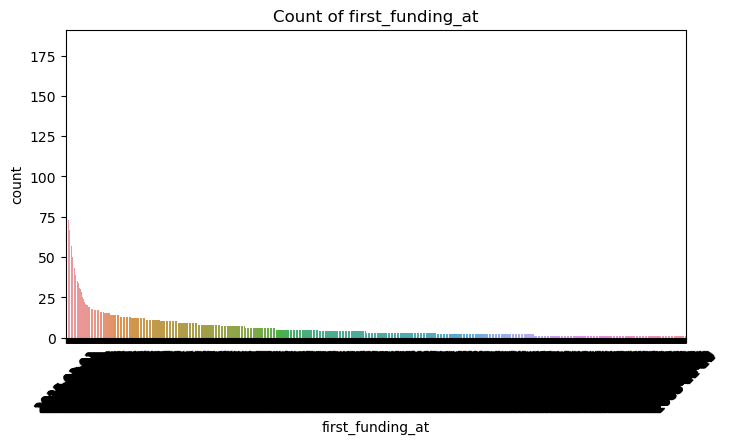

Value counts for first_funding_at:
 2011-01-01    182
2012-01-01    170
2008-01-01    169
2007-01-01    144
2010-01-01    143
             ... 
2008-05-26      1
2007-08-03      1
2009-12-06      1
2008-10-22      1
2008-02-10      1
Name: first_funding_at, Length: 2695, dtype: int64 



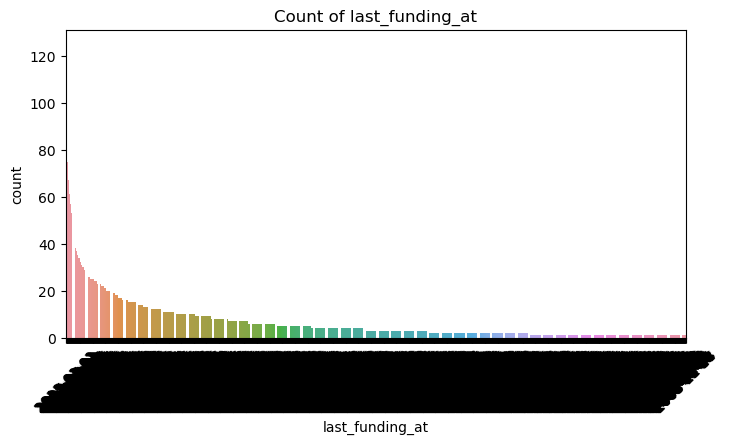

Value counts for last_funding_at:
 2011-01-01    125
2012-01-01    124
2008-01-01    113
2013-01-01     96
2010-01-01     95
             ... 
2009-05-23      1
2005-10-18      1
2008-12-24      1
2008-11-07      1
2009-10-08      1
Name: last_funding_at, Length: 2529, dtype: int64 



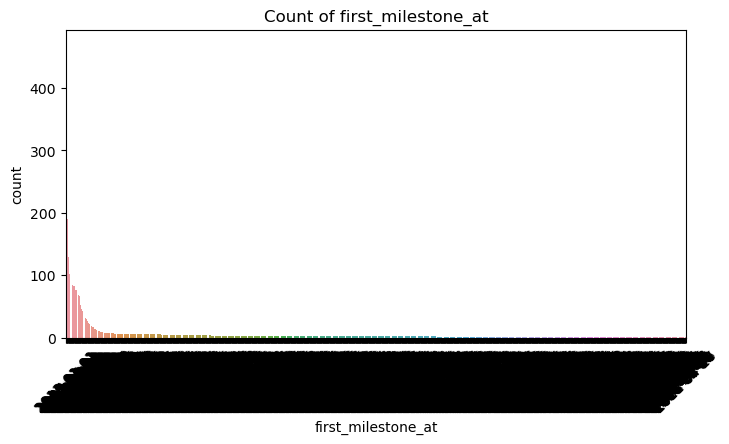

Value counts for first_milestone_at:
 2012-01-01    470
2011-01-01    380
2013-01-01    352
2010-01-01    272
2008-01-01    190
             ... 
1998-03-16      1
2010-12-30      1
2013-08-02      1
2011-07-16      1
2008-04-27      1
Name: first_milestone_at, Length: 1765, dtype: int64 



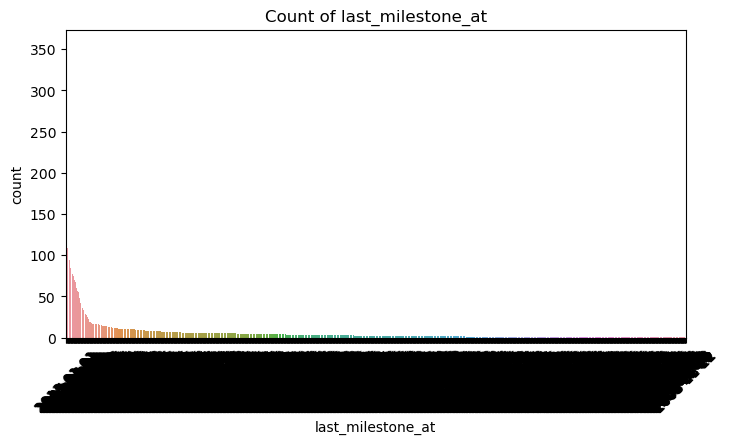

Value counts for last_milestone_at:
 2012-01-01    356
2013-01-01    308
2011-01-01    263
2010-01-01    186
2008-01-01    109
             ... 
2007-06-12      1
2002-08-01      1
2009-06-21      1
2009-08-22      1
2008-11-12      1
Name: last_milestone_at, Length: 1668, dtype: int64 



In [6]:
# Example numeric variable
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()
    print(f"Summary stats for {col}:\n", df[col].describe(), "\n")

# Example categorical variable
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Count of {col}")
    plt.xticks(rotation=45)
    plt.show()
    print(f"Value counts for {col}:\n", df[col].value_counts(), "\n")


# 5. Bivariate Analysis

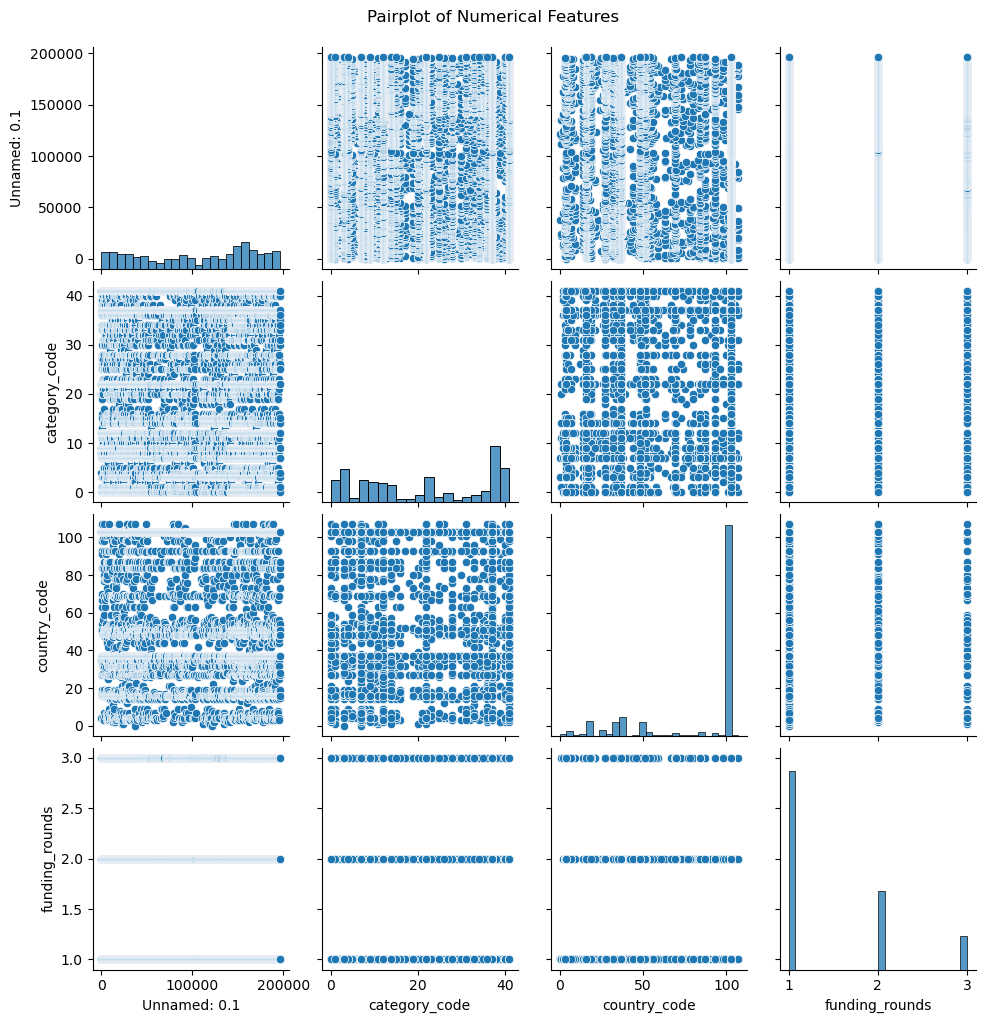

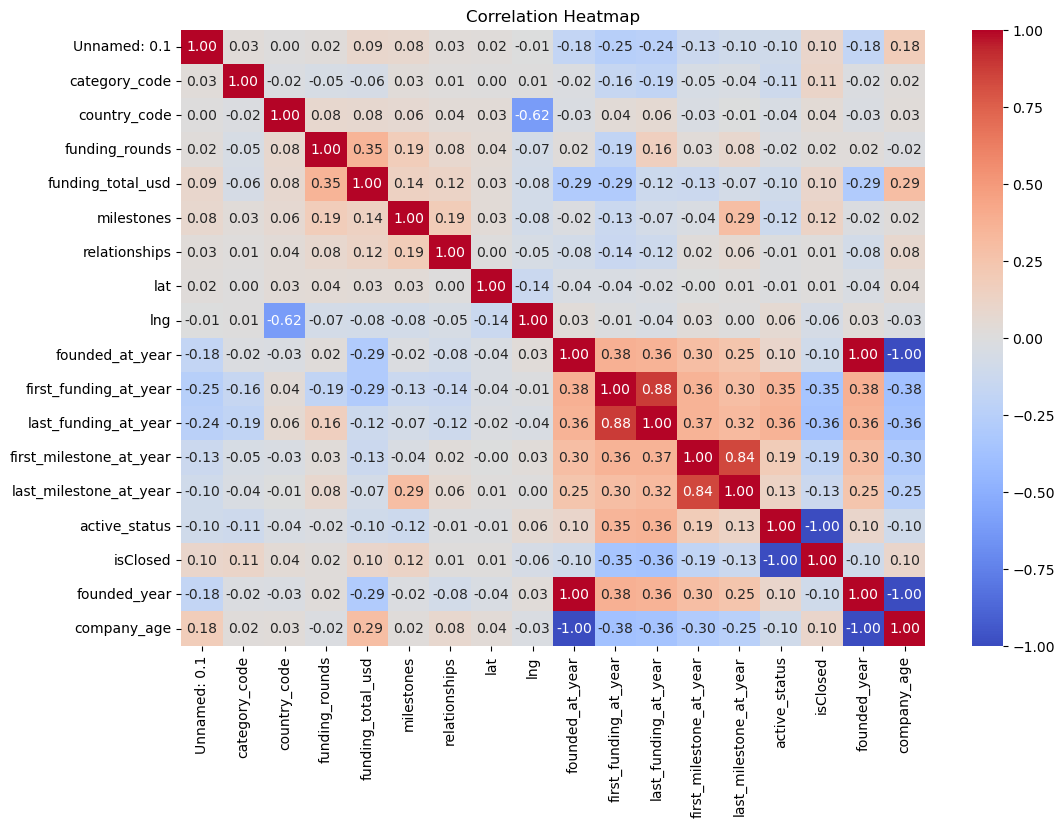

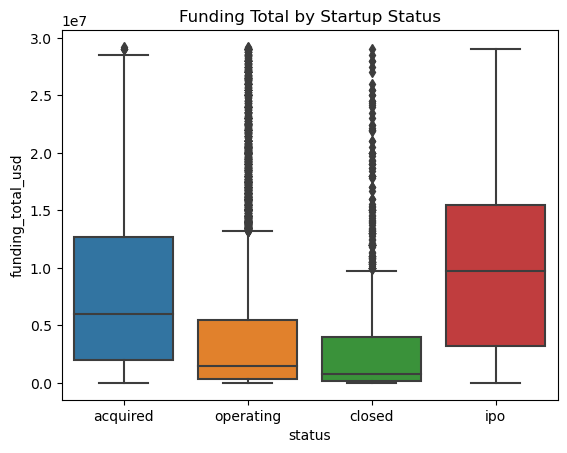

In [7]:
# Numeric vs Numeric
if len(numeric_cols) >= 2:
    sns.pairplot(df[numeric_cols[:4]])  # First few numeric vars
    plt.suptitle("Pairplot of Numerical Features", y=1.02)
    plt.show()

# Correlation matrix
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Categorical vs Numeric (Boxplots)
sns.boxplot(data=df, x='status', y='funding_total_usd')
plt.title("Funding Total by Startup Status")
plt.show()



# 5. Multivariate Analysis

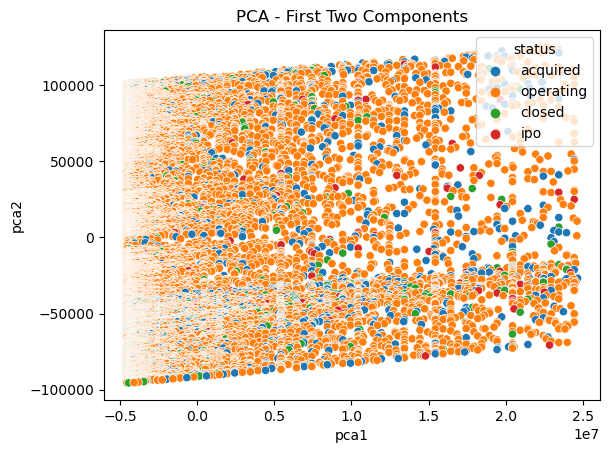

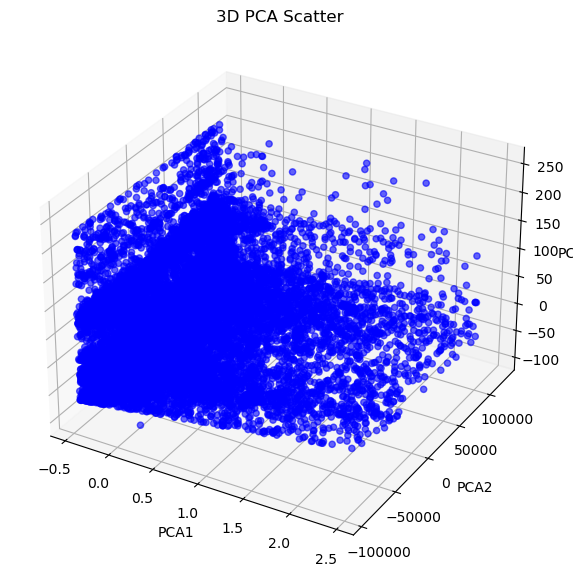

In [10]:
# --- PCA ---
# Keep only numeric data without NaN
numeric_df = df[numeric_cols].dropna(axis=1)

if numeric_df.shape[1] > 2:
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(numeric_df)
    df['pca1'], df['pca2'] = pca_result[:, 0], pca_result[:, 1]

    sns.scatterplot(data=df, x='pca1', y='pca2', hue=df[categorical_cols[0]] if len(categorical_cols) else None)
    plt.title("PCA - First Two Components")
    plt.show()

# --- 3D Plot Example ---
if numeric_df.shape[1] > 3:
    pca3 = PCA(n_components=3)
    pca_3d = pca3.fit_transform(numeric_df)
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(pca_3d[:, 0], pca_3d[:, 1], pca_3d[:, 2], c='blue', alpha=0.6)
    ax.set_title("3D PCA Scatter")
    ax.set_xlabel("PCA1")
    ax.set_ylabel("PCA2")
    ax.set_zlabel("PCA3")
    plt.show()


# 5. Conclusion & Insights Template

In [11]:
print("""
----------------------------------------
Key EDA Insights
----------------------------------------
1. Most frequent categories:
   {}
2. Funding distribution is skewed with few high outliers.
3. Company age shows {} median years.
4. Strong correlations observed between funding_total_usd and funding_rounds.
5. PCA reveals clusters separating companies by closure/active status.
----------------------------------------
""".format(
    df[categorical_cols[0]].value_counts().head(5) if len(categorical_cols) else "No categorical data",
    df['company_age'].median() if 'company_age' in df.columns else "N/A"
))





----------------------------------------
Key EDA Insights
----------------------------------------
1. Most frequent categories:
   operating    14352
acquired      1340
closed        1057
ipo            133
Name: status, dtype: int64
2. Funding distribution is skewed with few high outliers.
3. Company age shows 16.0 median years.
4. Strong correlations observed between funding_total_usd and funding_rounds.
5. PCA reveals clusters separating companies by closure/active status.
----------------------------------------

